# Circuit gallery: *look* at the circuits

This notebook **draws** the circuits, so you can visually confirm each
construction does exactly what it should. Every diagram is produced by
[`draw_circuit`](../../src/sparsegf2/circuits/draw.py), a
[quantikz2](https://arxiv.org/abs/1809.03842) LaTeX renderer over the same trace
IR as the text inspector, so it works for **every** picture / graph / gating /
matching / measurement mode automatically.

**How to read a diagram**
- One horizontal **wire per qubit**, `q0` at the top; time flows left→right, with
  dashed **`setup` / `t_1`, `t_2`, …** separators marking the individual timesteps.
- **System qubits are black wires, the reference register is red** (in
  `purification` / `single_ref`), so the Bell-paired references are unmistakable.
- Each box is a gate: `H` and a `CX` (filled control dot + ⊕ target) for the
  Bell-pair setup, and `C[index]` for a random two-qubit Clifford (the index into
  the 720-element Sp(4) table (same seed ⇒ same index, so it is reproducible). A
  long-range two-qubit gate is two boxes joined by a vertical wire.
- A **meter** is a `Z` measurement that **fired**.

`draw_circuit(cfg)` shows the compiled diagram inline; this needs a LaTeX install
(TeX Live ships `quantikz`) plus a PDF→PNG tool (`pdftoppm` / `sips` / ImageMagick).
Without LaTeX it returns the quantikz source string instead.

Quick start:
```python
from sparsegf2.circuits import CircuitConfig, draw_circuit
draw_circuit(CircuitConfig(graph_spec="cycle", n=4, picture="single_ref", p=0.16), max_layers=4)
```

## Setup

In [1]:
from IPython.display import display
from sparsegf2.circuits import (
    draw_circuit, inspect_circuit, trace_circuit, CircuitConfig,
)
print('ready: drawing with quantikz2')


ready: drawing with quantikz2


## 1. The golden path: anatomy of a diagram

`pure_state` on a `cycle(8)` with brickwork gates and bernoulli measurements.
Read it left to right: there is no setup (the state is $|0^8\rangle$), then each
timestep applies 4 random two-qubit Cliffords (a perfect matching of the ring)
and measures a random subset of qubits.

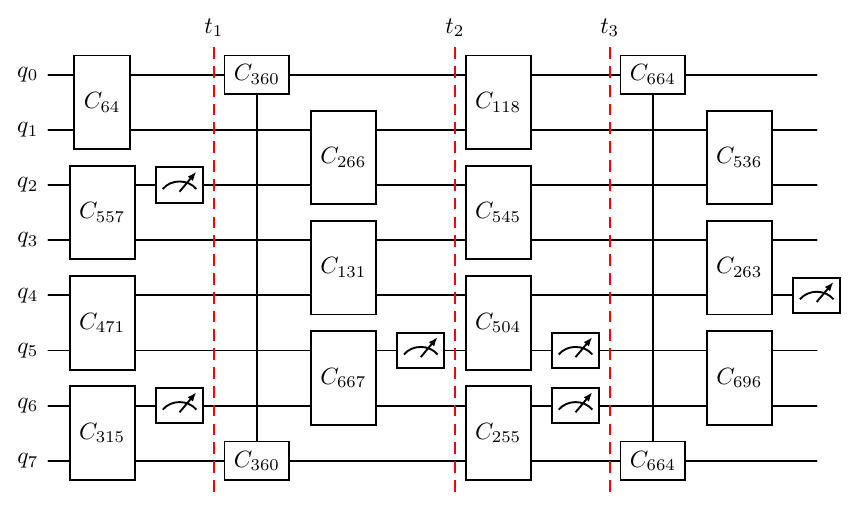

In [2]:
draw_circuit(CircuitConfig(graph_spec='cycle', n=8, p=0.16, depth_factor=2),
             sample_seed=0, max_layers=4)


## 2. How overlap is avoided (the column packer)

The priority for readability is that **no gate box is ever crossed by another
gate's connector line**. The drawer guarantees this by packing each stage's
operations into sub-columns via *greedy interval-graph coloring*: a two-qubit
gate occupies the wire interval `[min(qubits), max(qubits)]`, and two gates may
share a column only if their intervals are disjoint. Here is that logic, inline,
run on a real layer that contains the long-range cycle-wrap gate `(0, 7)`:

In [3]:
def pack(ops):
    '''Greedy interval coloring: the heart of draw.py::_pack_stage.'''
    columns = []                      # each column: list of occupied (lo,hi) intervals
    assign = {}
    for op in ops:
        lo, hi = min(op.qubits), max(op.qubits)
        for c, intervals in enumerate(columns):
            if all(hi < a or lo > b for a, b in intervals):  # disjoint with all in col c
                intervals.append((lo, hi)); assign[op.label] = c; break
        else:
            columns.append([(lo, hi)]); assign[op.label] = len(columns) - 1
    return assign, len(columns)

# grab a layer that includes the wrap edge (0,7)
cfg = CircuitConfig(graph_spec='cycle', n=8, p=0.0, depth_factor=2)
tr = trace_circuit(cfg, sample_seed=0, max_layers=3)
wrap_layer = next(s for s in tr.stages if s.kind == 'layer'
                  and any(abs(o.qubits[0]-o.qubits[1]) > 1 for o in s.ops if o.kind=='gate'))
gates = [o for o in wrap_layer.ops if o.kind == 'gate']
assign, ncols = pack(gates)
for o in gates:
    print(f'{o.label:>8} on {o.qubits} -> column {assign[o.label]}')
print(f'\n{len(gates)} gates packed into {ncols} columns with no interval overlap')


  C[360] on (0, 7) -> column 0
  C[266] on (1, 2) -> column 1
  C[131] on (3, 4) -> column 1
  C[667] on (5, 6) -> column 1

4 gates packed into 2 columns with no interval overlap


The wrap gate `(0,7)` spans the whole register, so it lands in its own column. Here is that exact circuit drawn (`p=0` so we see only the gates):

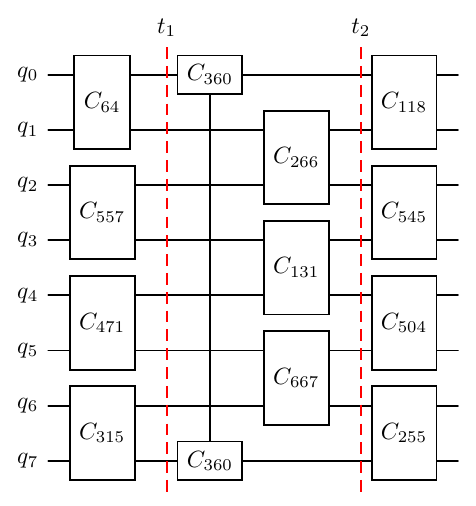

In [4]:
draw_circuit(cfg, sample_seed=0, max_layers=3)


## 3. The three pictures: verify the construction by eye

This is the payoff: you can **see** that each picture is wired correctly.

### `purification`: one Bell pair per system qubit
Each system qubit `i` gets `H(i)` then `CX(i → i+n)` to reference qubit `i+n`.
Below, count them: 6 Bell pairs (black system `q0-q5` each linked to its red
reference `q6-q11`), and the measured timesteps touch **only** system wires (the
red reference register is never measured).

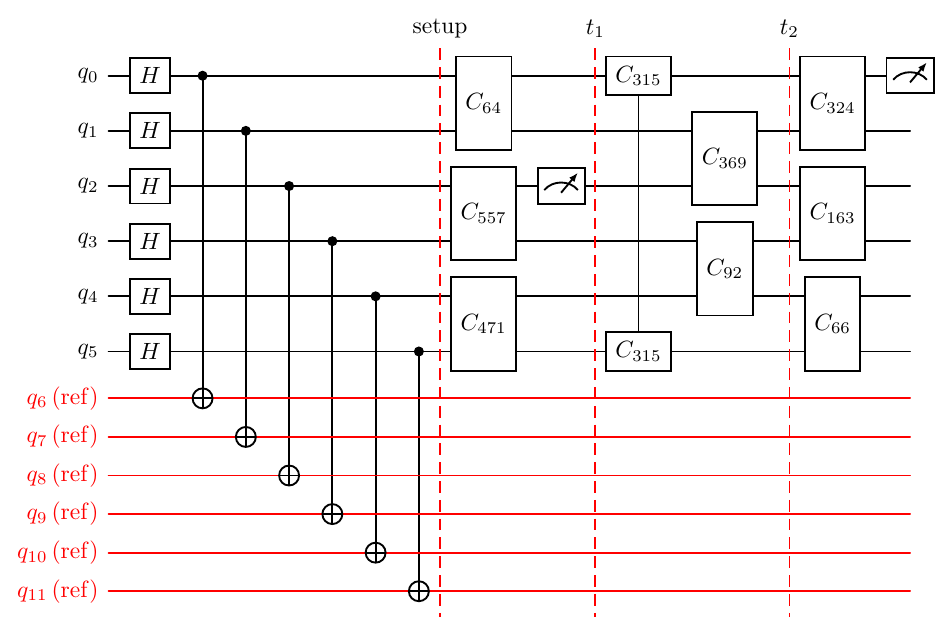

In [5]:
draw_circuit(CircuitConfig(graph_spec='cycle', n=6, picture='purification', p=0.16, depth_factor=2),
             sample_seed=0, max_layers=3)


### `single_ref`: exactly one Bell pair
One reference qubit (index `n`, red), Bell-paired with system qubit `n-1` via
`H(n-1); CX(n-1 → n)`. Everything else is the system; the reference is never
measured.

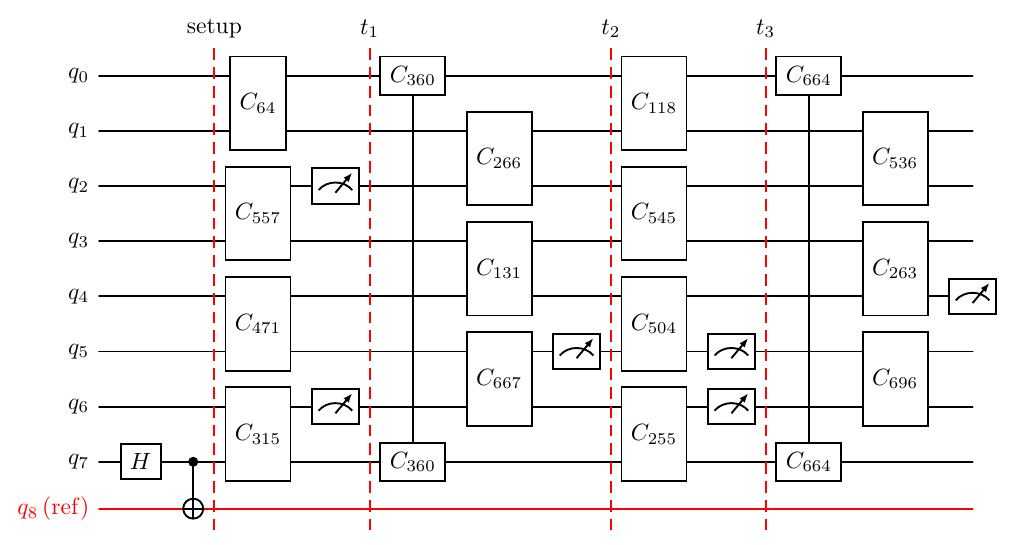

In [6]:
draw_circuit(CircuitConfig(graph_spec='cycle', n=8, picture='single_ref', p=0.16, depth_factor=2),
             sample_seed=0, max_layers=4)


### `pure_state`: no setup
$|0^n\rangle$, all wires are system (black), and there is no setup separator.

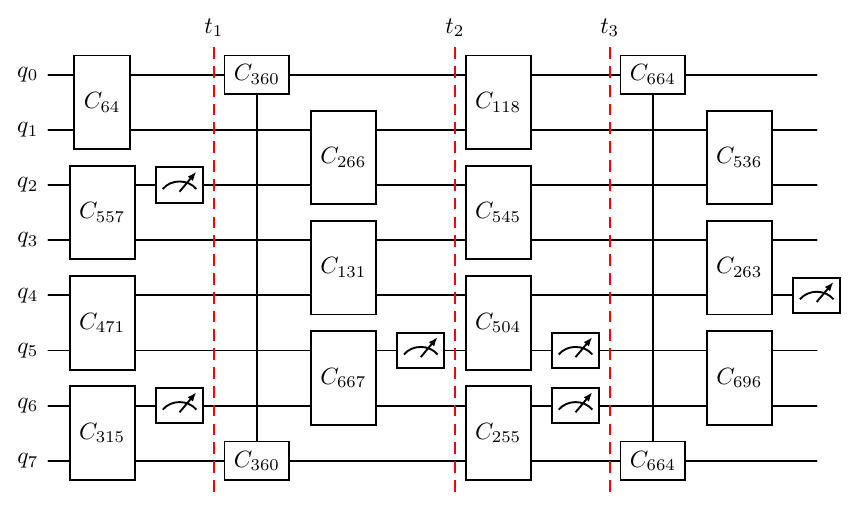

In [7]:
draw_circuit(CircuitConfig(graph_spec='cycle', n=8, picture='pure_state', p=0.16, depth_factor=2),
             sample_seed=0, max_layers=4)


## 4. Gating modes

**Brickwork** fires a whole perfect matching (n/2 gates) each timestep; the
matching mode picks *which* matching. On a cycle, `round_robin` strictly
alternates the two matchings (the gate pattern flips every timestep):

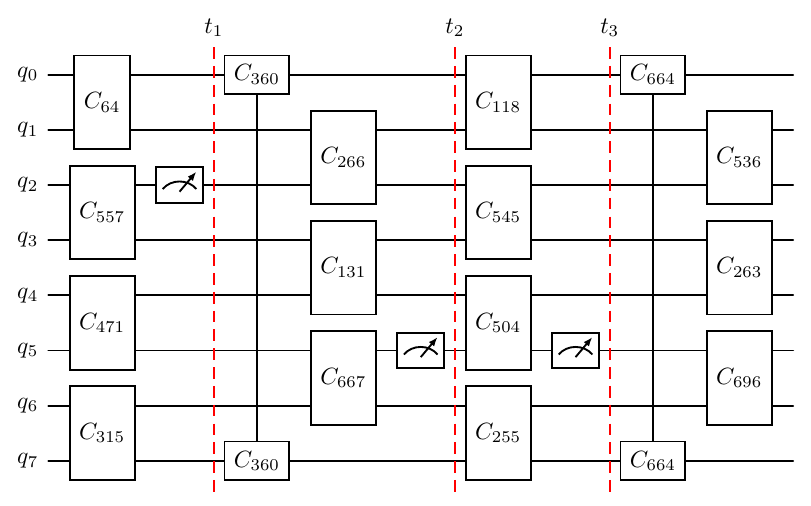

In [8]:
draw_circuit(CircuitConfig(graph_spec='cycle', n=8, matching_mode='round_robin', p=0.1, depth_factor=2),
             sample_seed=0, max_layers=4)


**`random_edge`** fires `gates_per_layer` random edges instead of a full
matching. With `gates_per_layer=1` it is a single gate per step (so the circuit
runs `O(n^2)` layers to do comparable work, see the `config` notebook); with
`gates_per_layer=n//2` it is the "O(n) random edges per step" model. The edges
may share vertices (not a matching), which you can see directly:

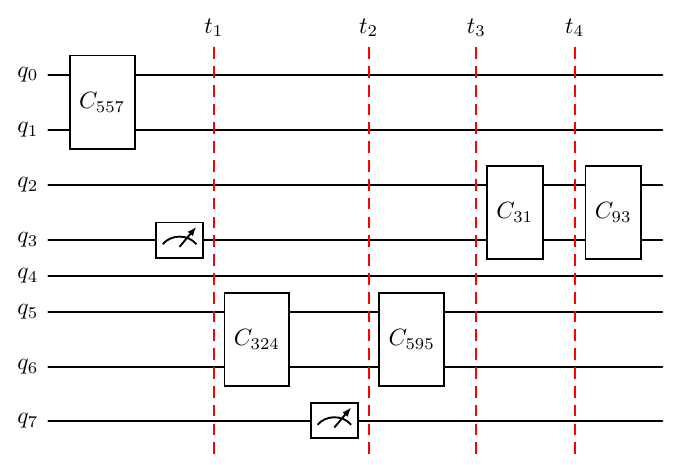

In [9]:
draw_circuit(CircuitConfig(graph_spec='cycle', n=8, gating_mode='random_edge', gates_per_layer=1, p=0.1, depth_factor=2),
             sample_seed=0, max_layers=5)


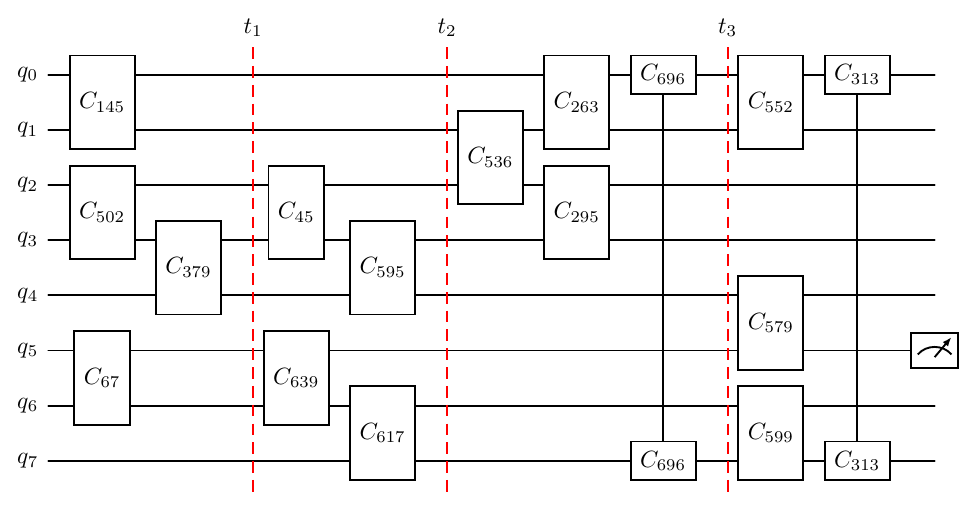

In [10]:
draw_circuit(CircuitConfig(graph_spec='cycle', n=8, gating_mode='random_edge', gates_per_layer=4, p=0.1, depth_factor=2),
             sample_seed=0, max_layers=4)


## 5. Measurement modes

Measurement is two steps: a mode-specific **candidate** set of eligible qubits is
chosen, then each candidate is *measured with probability p*. The candidate set
differs by mode: `bernoulli` → every qubit is a candidate; `gated` → only the
qubits this timestep's gates touched; `random_pair` → exactly 2 random qubits.

The diagram shows the meters that **fired**. To see the full candidate set (which
qubits were eligible, not just which fired), use the **text inspector**, which lists
candidates and fired separately. Below, the same seed across the three modes:

measurement_mode = bernoulli


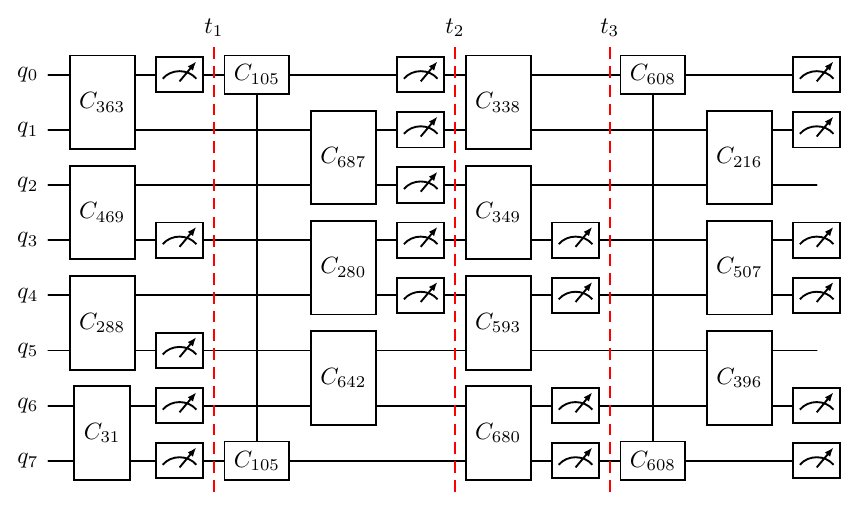

measurement_mode = gated


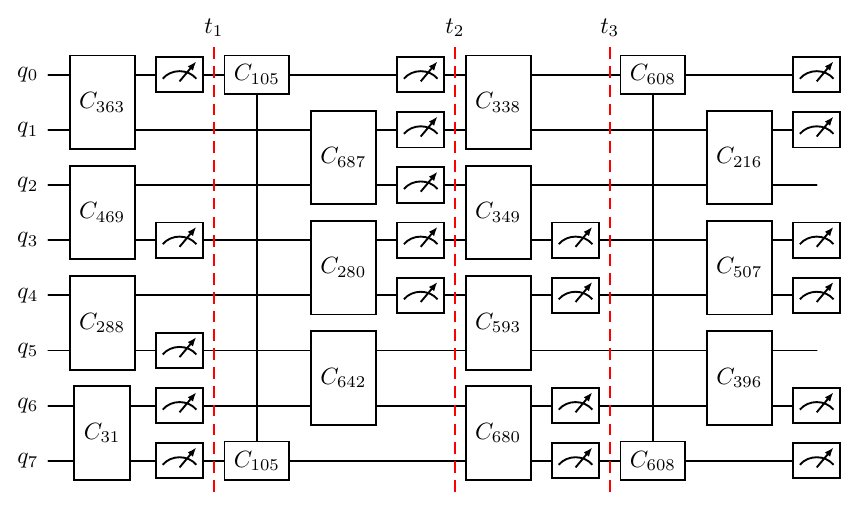

measurement_mode = random_pair


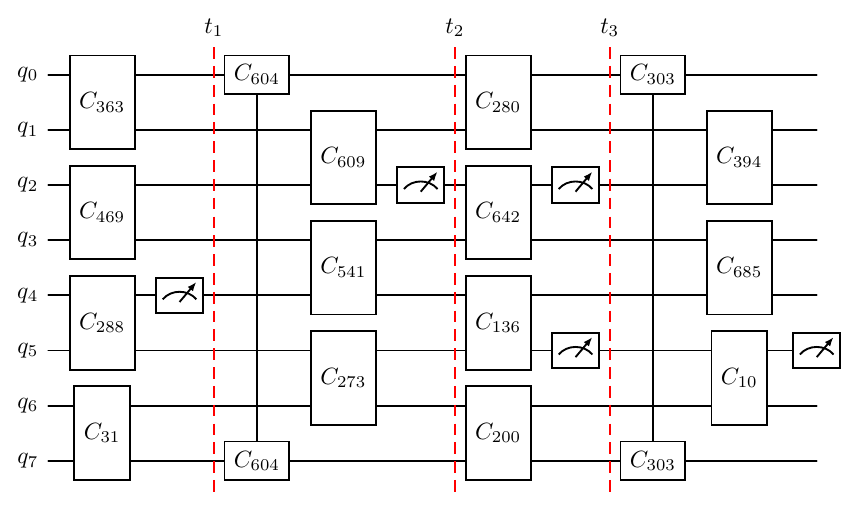

In [11]:
for mm in ('bernoulli', 'gated', 'random_pair'):
    print('measurement_mode =', mm)
    display(draw_circuit(CircuitConfig(graph_spec='cycle', n=8, measurement_mode=mm, p=0.5, depth_factor=2),
                         sample_seed=1, max_layers=4))


The text view makes the candidate-vs-fired split explicit (here `bernoulli`
at `p=0.2`, where every qubit is a candidate each timestep but only ~1 in 5
fire):

In [12]:
print(inspect_circuit(CircuitConfig(graph_spec='cycle', n=8, measurement_mode='bernoulli', p=0.2, depth_factor=2),
                      sample_seed=3, max_layers=3))


Circuit inspection: first 3 of 16 measured layers
  picture        : pure_state  (8 qubits (all system))
  graph          : cycle(8)
  gating         : brickwork / round_robin
  measurement    : bernoulli  p=0.2
  depth          : O(n) ×2 = 16 measured layers
  exp. gate:meas : 2.5 : 1
  sample_seed    : 3

setup (none: |0…0⟩)

layer 0
  2q gates [random Sp(4)]:  C[665] (q0,q1)   C[412] (q2,q3)   C[526] (q4,q5)   C[380] (q6,q7)
  measure Z  fired [none]   candidates [q0 q1 q2 q3 q4 q5 q6 q7]

layer 1
  2q gates [random Sp(4)]:  C[369] (q0,q7)   C[451] (q1,q2)   C[590] (q3,q4)   C[604] (q5,q6)
  measure Z  fired [q7]   candidates [q0 q1 q2 q3 q4 q5 q6 q7]

layer 2
  2q gates [random Sp(4)]:  C[307] (q0,q1)   C[39] (q2,q3)   C[213] (q4,q5)   C[86] (q6,q7)
  measure Z  fired [q1 q5 q6 q7]   candidates [q0 q1 q2 q3 q4 q5 q6 q7]

… 13 more measured layers not shown (raise max_layers to see them).



## 6. Graphs: connectivity is visible

A `cycle` keeps gates nearest-neighbour (short connectors, plus the one wrap
edge); a `complete` graph lets any pair interact (many long-range gates joined by
vertical wires). Same seed, same everything else, so only the graph differs:

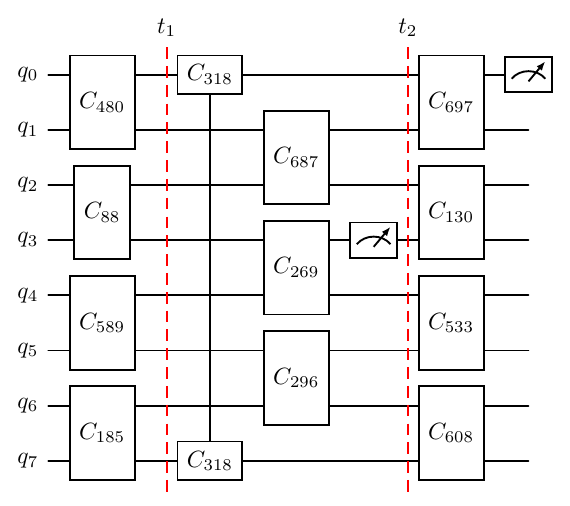

In [13]:
draw_circuit(CircuitConfig(graph_spec='cycle', n=8, p=0.1, depth_factor=2),
             sample_seed=2, max_layers=3)


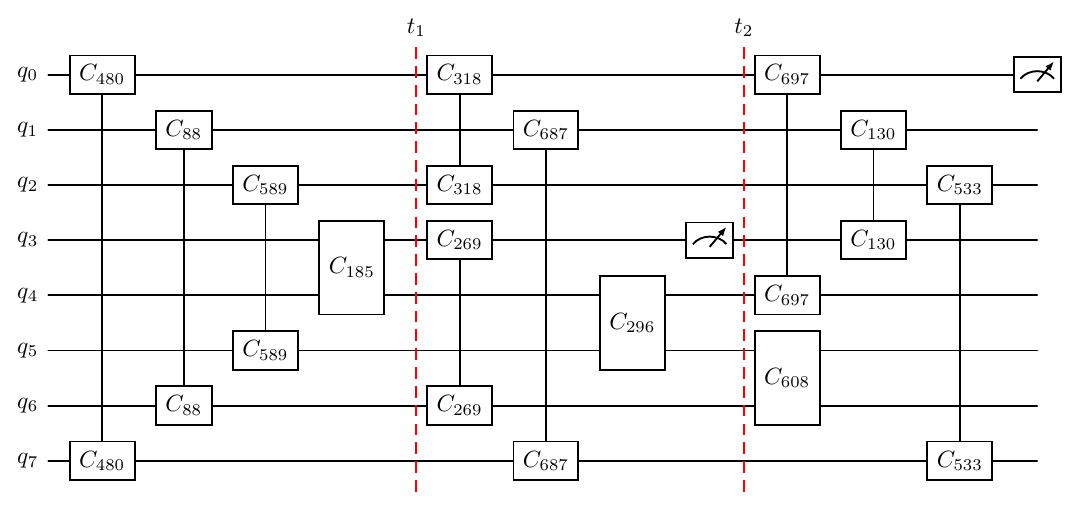

In [14]:
draw_circuit(CircuitConfig(graph_spec='complete', n=8, p=0.1, depth_factor=2),
             sample_seed=2, max_layers=3)


## 7. The three pictures side by side

Display them in sequence to see the growing setup region (none → one Bell pair →
one per qubit):

picture = pure_state


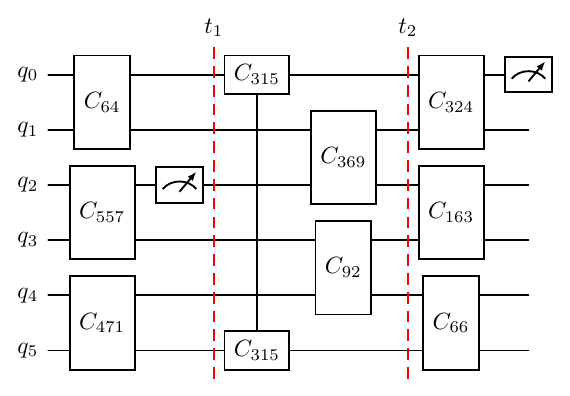

picture = single_ref


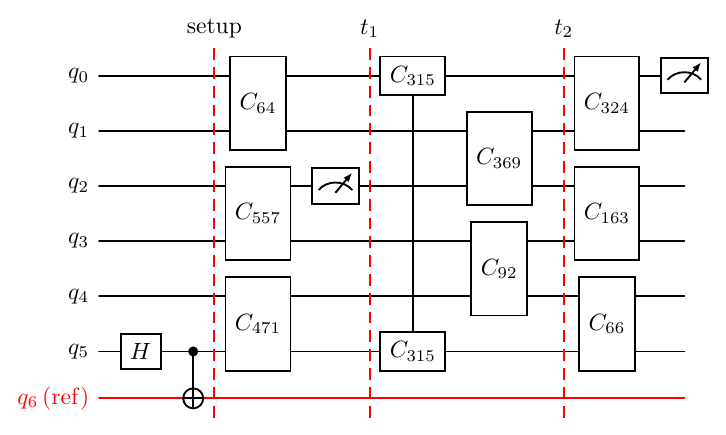

picture = purification


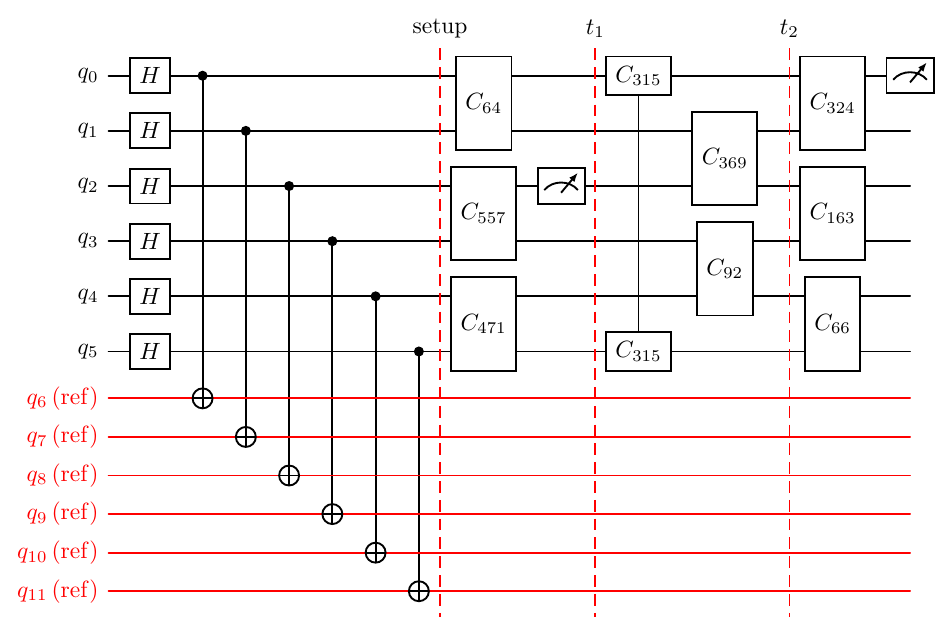

In [15]:
for pic in ('pure_state', 'single_ref', 'purification'):
    print('picture =', pic)
    display(draw_circuit(CircuitConfig(graph_spec='cycle', n=6, picture=pic, p=0.16, depth_factor=2),
                         sample_seed=0, max_layers=3))


## 8. The other two views (text + CLI)

The diagram, the text inspector, and the CLI all read the same trace, so they
always agree. The **text** view is handy for exact indices / scripting:

In [16]:
print(inspect_circuit(CircuitConfig(graph_spec='cycle', n=8, picture='single_ref', p=0.16, depth_factor=2),
                      sample_seed=0, max_layers=3))


Circuit inspection: first 3 of 16 measured layers
  picture        : single_ref  (9 qubits: system 0-7, reference [8])
  graph          : cycle(8)
  gating         : brickwork / round_robin
  measurement    : bernoulli  p=0.16
  depth          : O(n) ×2 = 16 measured layers
  exp. gate:meas : 3.12 : 1
  sample_seed    : 0

setup (deterministic)
  H     q7
  CX    q7→q8   # Bell pair: system 7 ↔ reference 8

layer 0
  2q gates [random Sp(4)]:  C[64] (q0,q1)   C[557] (q2,q3)   C[471] (q4,q5)   C[315] (q6,q7)
  measure Z  fired [q2 q6]   candidates [q0 q1 q2 q3 q4 q5 q6 q7]

layer 1
  2q gates [random Sp(4)]:  C[360] (q0,q7)   C[266] (q1,q2)   C[131] (q3,q4)   C[667] (q5,q6)
  measure Z  fired [q5]   candidates [q0 q1 q2 q3 q4 q5 q6 q7]

layer 2
  2q gates [random Sp(4)]:  C[118] (q0,q1)   C[545] (q2,q3)   C[504] (q4,q5)   C[255] (q6,q7)
  measure Z  fired [q5 q6]   candidates [q0 q1 q2 q3 q4 q5 q6 q7]

… 13 more measured layers not shown (raise max_layers to see them).



From the shell:
```sh
python scripts/inspect_circuit.py --n 8 --picture single_ref --layers 12
```

To write a diagram to a file instead of showing it inline, use
`save_circuit(cfg, "circuit.pdf")` (or `.png` / `.tex`); `circuit_to_quantikz(cfg)`
returns the LaTeX source directly, no compiler needed.

## Summary

- `draw_circuit(config_or_trace, max_layers=…)` draws any construction inline; it
  is a quantikz renderer over the trace IR, so new pictures / graphs / modes are
  drawn automatically.
- System wires are black, the reference register is red; dashed `setup` / `t_k`
  separators mark the timesteps; meters are measurements that fired.
- The column packer guarantees no gate box is crossed by another gate's connector.
  Drawing needs a LaTeX install (the simulator floor stays numpy + numba).

To inspect *your* config, just call `draw_circuit(CircuitConfig(...))`.